# Build graph on ALL ships in the focus zone only


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import pickle

base_dir = Path("/users/eleves-b/2023/marc.saade/bachelor-thesis/thesis")
by_ship_dir = base_dir / "data" / "processed" / "by_ship_jul"

# Final focus zone for thesis (matches GNN_model visual)
# Approx: lat ~ 15–40N, lon ~ -100–-60W
FOCUS_LAT = (15, 40)
FOCUS_LON = (-100, -60)

print("FOCUS_LAT:", FOCUS_LAT, "FOCUS_LON:", FOCUS_LON)

FOCUS_LAT: (15, 40) FOCUS_LON: (-100, -60)


In [2]:
# Build routes_df in a single pass, keeping ONLY points inside FOCUS_LAT/FOCUS_LON
ship_files = list(by_ship_dir.glob("MMSI_*.parquet"))
routes = []

for f in ship_files:
    # Read only the columns we need for the graph
    df = pd.read_parquet(f, columns=["mmsi", "base_date_time", "LAT", "LON"])
    mask = (
        (df["LAT"] >= FOCUS_LAT[0]) & (df["LAT"] <= FOCUS_LAT[1]) &
        (df["LON"] >= FOCUS_LON[0]) & (df["LON"] <= FOCUS_LON[1])
    )
    df = df[mask].copy()
    if df.empty:
        continue
    df["MMSI"] = df["mmsi"].astype("int64")
    routes.append(df[["MMSI", "base_date_time", "LAT", "LON"]])

if not routes:
    raise ValueError("No AIS points found inside FOCUS_LAT/FOCUS_LON. Check the bounds.")

routes_df = pd.concat(routes, ignore_index=True)
print(f"routes_df: {len(routes_df):,} rows, {routes_df['MMSI'].nunique():,} ships")

routes_df: 103,143,160 rows, 18,940 ships


In [3]:
# routes_df is ready from the previous cell
routes_df.head()

,MMSI,base_date_time,LAT,LON
0,103669999,2024-07-01 00:00:19,30.36442,-89.08703
1,103669999,2024-07-01 00:00:19,30.36442,-89.08703
2,103669999,2024-07-01 00:03:19,30.36443,-89.08702
3,103669999,2024-07-01 00:03:19,30.36443,-89.08702
4,103669999,2024-07-01 00:09:19,30.36443,-89.08702


In [4]:
# Build route graph (same grid and function as GNN_model)
from math import radians, sin, cos, sqrt, atan2
import networkx as nx

LAT_STEP = 0.01
LON_STEP = 0.01

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return R * c

def build_route_graph(df, lat_step=LAT_STEP, lon_step=LON_STEP):
    df = df.sort_values(["MMSI", "base_date_time"]).copy()
    df["lat_bin"] = (df["LAT"] / lat_step).round().astype(int)
    df["lon_bin"] = (df["LON"] / lon_step).round().astype(int)
    df["node_key"] = list(zip(df["lat_bin"], df["lon_bin"]))
    unique_nodes = df[["node_key", "LAT", "LON"]].groupby("node_key").agg({"LAT": "mean", "LON": "mean"}).reset_index()
    node_id_map = {key: i for i, key in enumerate(unique_nodes["node_key"])}
    G = nx.DiGraph()
    for key, lat, lon in unique_nodes[["node_key", "LAT", "LON"]].itertuples(index=False):
        G.add_node(node_id_map[key], lat=lat, lon=lon)
    for mmsi, ship_df in df.groupby("MMSI"):
        ship_df = ship_df.reset_index(drop=True)
        for i in range(len(ship_df) - 1):
            a, b = ship_df.loc[i], ship_df.loc[i + 1]
            nid_a = node_id_map[a["node_key"]]
            nid_b = node_id_map[b["node_key"]]
            if nid_a == nid_b:
                continue
            dist = haversine_km(a["LAT"], a["LON"], b["LAT"], b["LON"])
            if G.has_edge(nid_a, nid_b):
                G[nid_a][nid_b]["count"] += 1
                G[nid_a][nid_b]["total_dist_km"] += dist
            else:
                G.add_edge(nid_a, nid_b, count=1, total_dist_km=dist)
    return G

G = build_route_graph(routes_df)
print(f"G: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

G: 837,959 nodes, 1,839,506 edges


In [5]:
# Save for GNN_training
out_path = base_dir / "graph_focus_zone_jul.pkl"
with open(out_path, "wb") as f:
    pickle.dump(G, f)
print(f"Saved to {out_path}")

Saved to /users/eleves-b/2023/marc.saade/bachelor-thesis/thesis/graph_focus_zone_jul.pkl


In [6]:
from pathlib import Path
import pickle

base_dir = Path("/users/eleves-b/2023/marc.saade/bachelor-thesis/thesis")
graph_path = base_dir / "graph_focus_zone.pkl"

print("Loading graph from:", graph_path)
with open(graph_path, "rb") as f:
    G = pickle.load(f)

print(f"G: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

Loading graph from: /users/eleves-b/2023/marc.saade/bachelor-thesis/thesis/graph_focus_zone.pkl


G: 623,661 nodes, 1,250,088 edges


routes_df: 103,143,160 points, 18,940 ships


Plotting a sample of 500,000 points


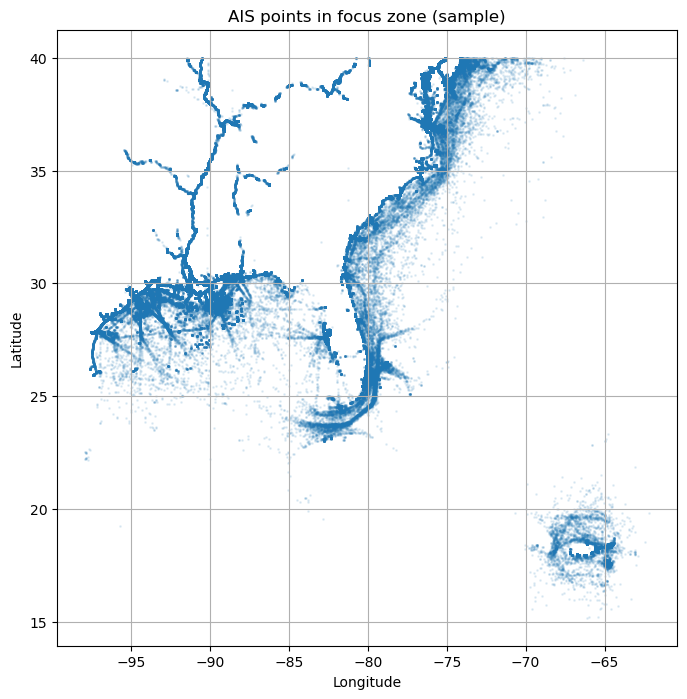

In [7]:
# Visualize a random sample of AIS points in the focus zone
import matplotlib.pyplot as plt

print(f"routes_df: {len(routes_df):,} points, {routes_df['MMSI'].nunique():,} ships")

# Sample for plotting (to avoid 62M points on a single figure)
N_SAMPLE = 500_000
if len(routes_df) > N_SAMPLE:
    plot_df = routes_df.sample(n=N_SAMPLE, random_state=0)
    print(f"Plotting a sample of {N_SAMPLE:,} points")
else:
    plot_df = routes_df
    print("Plotting all points")

plt.figure(figsize=(8, 8))
plt.scatter(plot_df["LON"], plot_df["LAT"], s=1, alpha=0.1)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("AIS points in focus zone (sample)")
plt.grid(True)
plt.show()

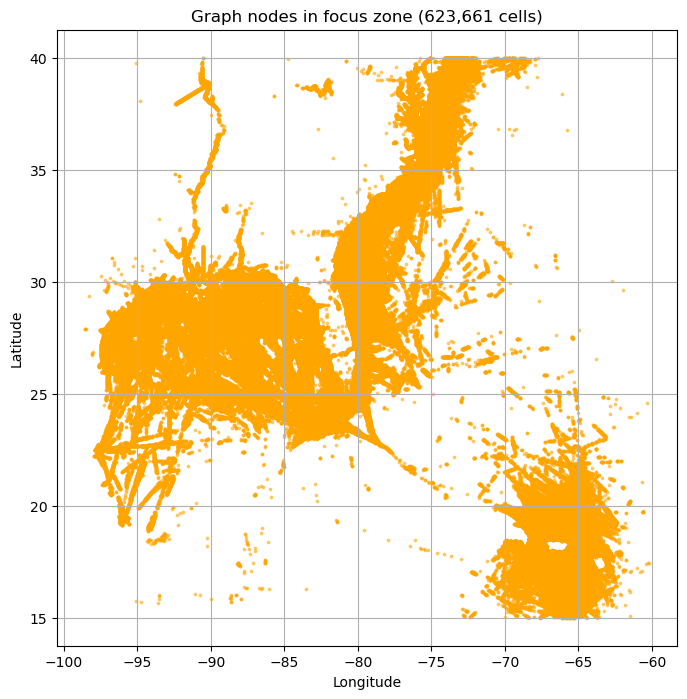

In [8]:
# Visualize graph nodes (grid cells) that G contains
node_lats = [G.nodes[n]["lat"] for n in G.nodes()]
node_lons = [G.nodes[n]["lon"] for n in G.nodes()]

plt.figure(figsize=(8, 8))
plt.scatter(node_lons, node_lats, s=3, alpha=0.5, color="orange")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"Graph nodes in focus zone ({G.number_of_nodes():,} cells)")
plt.grid(True)
plt.show()

/users/eleves-b/2023/marc.saade/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


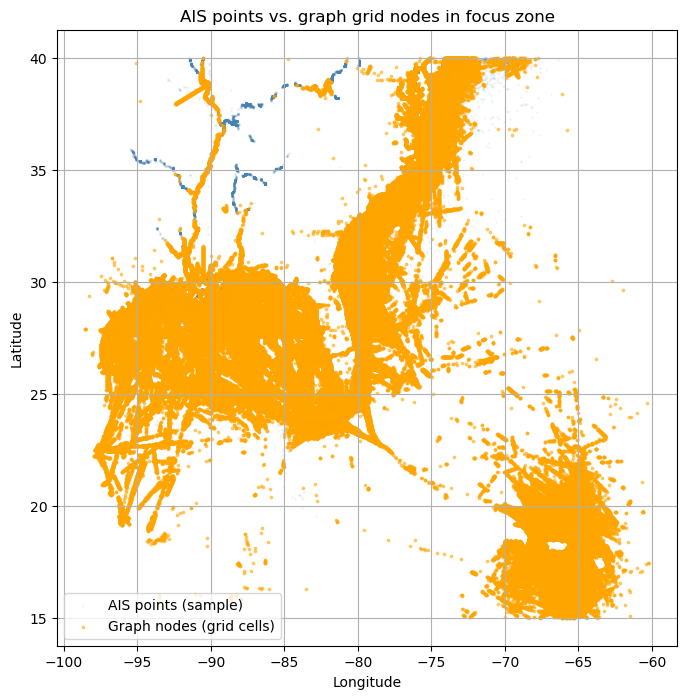

In [9]:
plt.figure(figsize=(8, 8))

# AIS sample in light blue
plt.scatter(plot_df["LON"], plot_df["LAT"], s=1, alpha=0.05, color="steelblue", label="AIS points (sample)")

# Grid nodes in orange
plt.scatter(node_lons, node_lats, s=3, alpha=0.5, color="orange", label="Graph nodes (grid cells)")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("AIS points vs. graph grid nodes in focus zone")
plt.legend()
plt.grid(True)
plt.show()